Problem 1.

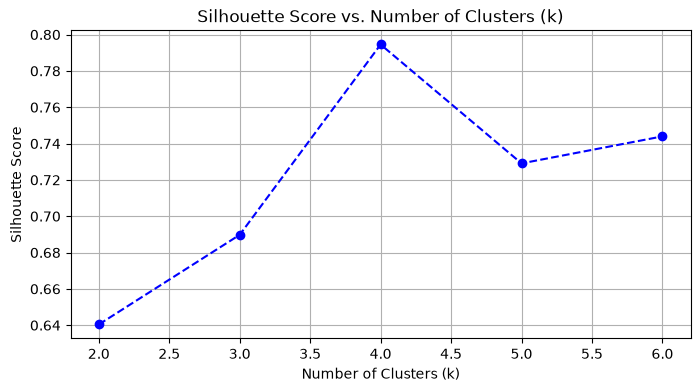

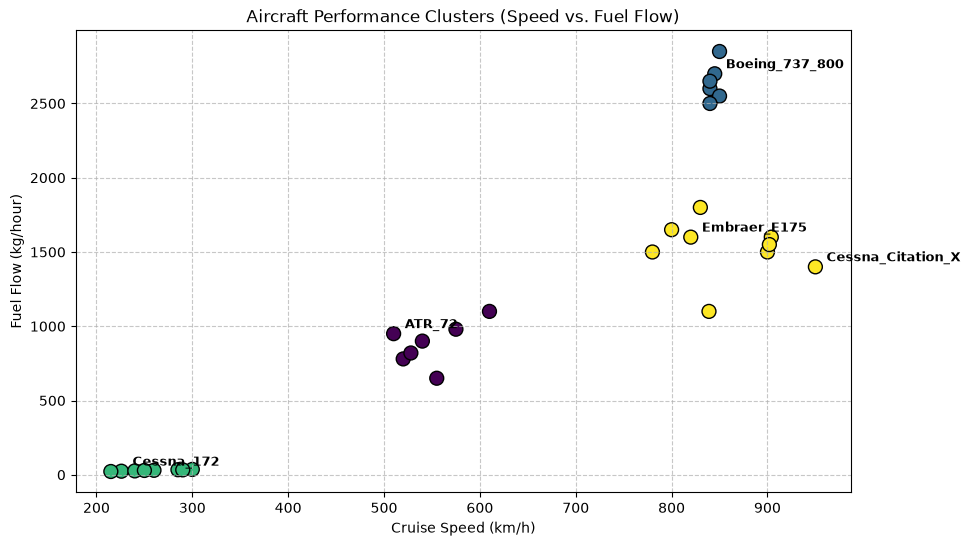

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('aircraft_performance.csv')

X = df[['Speed_kmh', 'FuelFlow_kgph']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Speed_kmh'], df['FuelFlow_kgph'],
                      c=df['Cluster'], cmap='viridis', s=100, edgecolors='k')

plt.title('Aircraft Performance Clusters (Speed vs. Fuel Flow)')
plt.xlabel('Cruise Speed (km/h)')
plt.ylabel('Fuel Flow (kg/hour)')
plt.grid(True, linestyle='--', alpha=0.7)

representative_aircraft = [
    'Cessna_172',        # General Aviation Piston
    'ATR_72',            # Regional Turboprop
    'Embraer_E175',      # Regional Jet
    'Boeing_737_800',    # Commercial Narrow-Body Jet
    'Cessna_Citation_X'  # High-Speed Business Jet
]

for _, row in df.iterrows():
    if row['Aircraft'] in representative_aircraft:
        plt.annotate(
            row['Aircraft'],
            (row['Speed_kmh'], row['FuelFlow_kgph']),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold'
        )

plt.show()


Lowest speed and fuel flow corresponds to general aviation aircraft. Moderate speed and fuel flow corresponds to turboprops. High speed, moderate fuel flow corresponds to small business jets. High speed and fuel flow corresponds to commercial airliners.

Problem 2.

Predictions for a city with population of 160,000 (x = 16):
-------------------------------------------------------
Batch Size  1 -> Predicted Price: 12.8410 (in $10,000s)
Batch Size  5 -> Predicted Price: 13.6995 (in $10,000s)
Batch Size 10 -> Predicted Price: 12.8081 (in $10,000s)
Batch Size 20 -> Predicted Price: 13.3195 (in $10,000s)


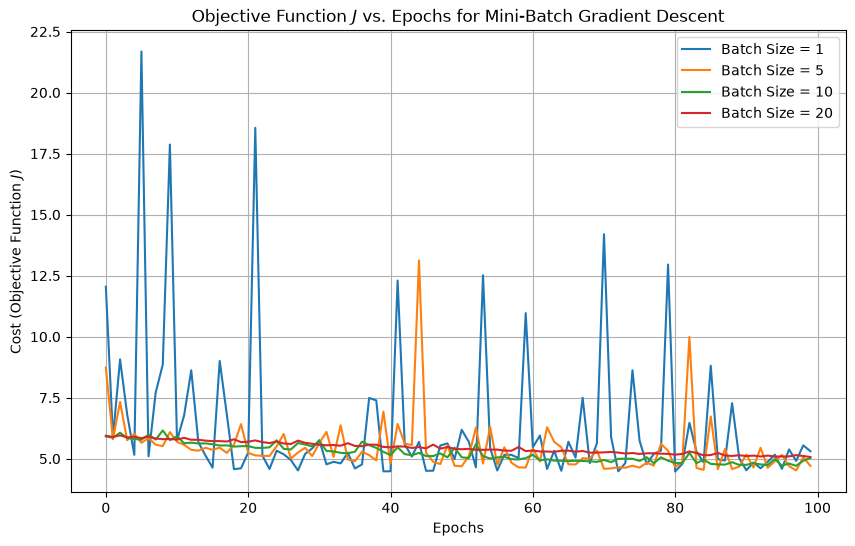

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("housing_prices.txt", delimiter=",")
X = data[:, 0]
y = data[:, 1]
m = len(y)

X_b = np.c_[np.ones((m, 1)), X]

def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    return cost

def mini_batch_gradient_descent(X, y, batch_size, learning_rate=0.005, epochs=50):
    m = len(y)
    theta = np.zeros(2)
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_i = X_shuffled[i:i + batch_size]
            y_i = y_shuffled[i:i + batch_size]
            m_i = len(y_i)

            predictions = X_i.dot(theta)
            gradient = (1 / m_i) * X_i.T.dot(predictions - y_i)
            theta = theta - learning_rate * gradient

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

batch_sizes = [1, 5, 10, 20]
learning_rate = 0.005
epochs = 100

plt.figure(figsize=(10, 6))

print("Predictions for a city with population of 160,000 (x = 16):\n" + "-"*55)

for batch_size in batch_sizes:
    theta, cost_history = mini_batch_gradient_descent(X_b, y, batch_size, learning_rate, epochs)

    plt.plot(range(epochs), cost_history, label=f'Batch Size = {batch_size}')

    prediction_normalized = np.array([1, 16]).dot(theta)
    print(f"Batch Size {batch_size:2d} -> Predicted Price: {prediction_normalized:.4f} (in $10,000s)")

plt.title('Objective Function $J$ vs. Epochs for Mini-Batch Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('Cost (Objective Function $J$)')
plt.legend()
plt.grid(True)
plt.show()

Problem 3.

Classification Metrics
Accuracy:  0.9649
Precision: 0.9722
Recall:    0.9722
F1-Score:  0.9722


Detailed Classification Report
              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        63
      benign       0.97      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



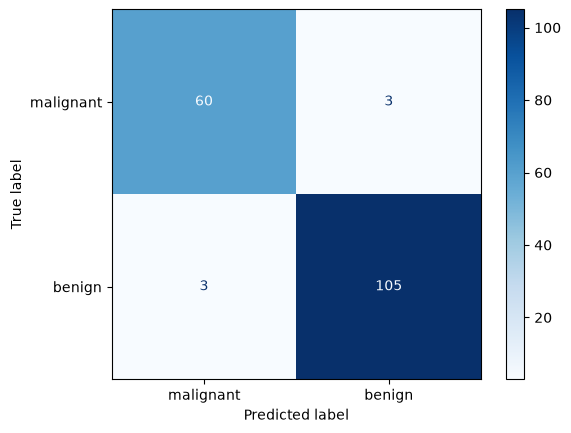

In [21]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)

rfe = RFE(estimator=logreg, n_features_to_select=2)
rfe.fit(X_train_scaled, y_train)

y_pred = rfe.predict(X_test_scaled)

print("Classification Metrics")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}\n")

disp.ax_.set_title("Logistic Regression Confusion Matrix (2 Features)")
plt.show()
print("\nDetailed Classification Report")
print(classification_report(y_test, y_pred, target_names=data.target_names))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=data.target_names,
    cmap=plt.cm.Blues
)


Problem 4.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted price for a population of 165,000: $59,246.39
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Validation Mean Absolute Error (MAE): 4.0589
Validation R-squared: -0.0037


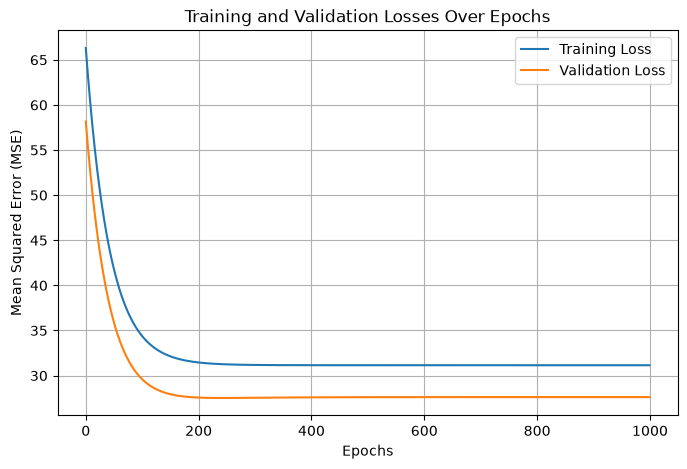

In [24]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

data = np.loadtxt('housing_prices.txt', delimiter=',')
X = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1)
])

learning_rate = 0.002
epochs = 1000

optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='mse')

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, verbose=0)

pop_input = np.array([[16.5]])
predicted_price = model.predict(pop_input)

print(f"Predicted price for a population of 165,000: ${predicted_price[0][0] * 10000:,.2f}")

y_pred_val = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)
print(f"Validation Mean Absolute Error (MAE): {mae:.4f}")
print(f"Validation R-squared: {r2:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

The training and validation losses drop sharply at the beginning, as the randomly initialized weights adjust quickly to fit the dataset. At about 300 epochs, the losses plateau as the model fits well to the data. There is no notable overfitting as training and validation losses remain constant after this point.